In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/8vo/data/Flowers"
!pwd

Mounted at /content/drive
/content/drive/MyDrive/8vo/data/Flowers
/content/drive/MyDrive/8vo/data/Flowers


### Primer modelo

In [2]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, GlobalAveragePooling2D, Dropout
import json

In [3]:
# Carga del dataset
base_dir = '/content/drive/MyDrive/8vo/data/Flowers'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'val') # Le puse test pq el chino que hizo el ds lo separó con el nombre val, pero es test

class_names = sorted(os.listdir(train_dir))
print(f"Clases ({len(class_names)}):", class_names)

Clases (14): ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [4]:
IMG_SIZE = (256, 256)

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir+"/train",
    image_size = IMG_SIZE,
    color_mode="rgb",
    batch_size = 10,
    shuffle = True,
    validation_split = 0.2,
    subset = "training",
    seed = 123
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir+"/train",
    image_size = IMG_SIZE,
    color_mode="rgb",
    batch_size = 10,
    shuffle = True,
    validation_split = 0.2,
    subset = "validation",
    seed = 123
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = 10,
    shuffle = True,
)


Found 13642 files belonging to 14 classes.
Using 10914 files for training.
Found 13642 files belonging to 14 classes.
Using 2728 files for validation.
Found 98 files belonging to 14 classes.


['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']
0.0 1.0


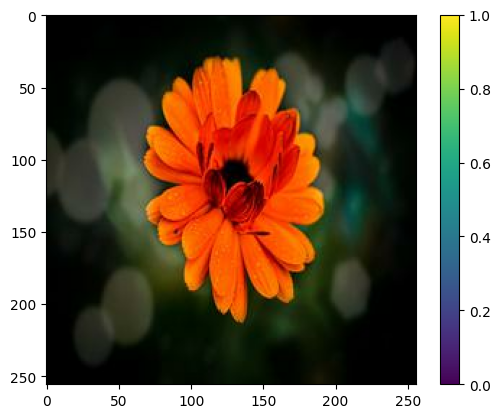

In [ ]:
print(train_ds.class_names) # Validar que sí asignara bien keras las labels

first_element = list(train_ds.take(1))[0]
prueba = first_element[0][0].numpy()
prueba = prueba / 255
print(prueba.min(), prueba.max())

plt.figure()
plt.imshow(prueba)
plt.colorbar()
plt.grid(False)
plt.show()



### Escalamiento de las imagenes y preprocesado (Data augmentation)

In [5]:
def AugmentAndScale(image, label):
    image = tf.cond(
        tf.reduce_max(image) > 1.0,
        lambda: image / 255.0,
        lambda: image
    )

    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_flip_left_right(image)



    return image, label

train_ds = train_ds.map(AugmentAndScale)
validation_ds = validation_ds.map(AugmentAndScale)
test_ds  = test_ds.map(AugmentAndScale)


print(train_ds)




<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


### Etapa 2
#### Primer modelo (visto en clase)

In [ ]:
def get_model_compiled(): # Modelo basado en las actividades vistas en clase, principalmente
                          # Cats&Dogs
  model = Sequential([
      Conv2D(filters=16, input_shape=(256,256,3), kernel_size=(3, 3), activation='relu', name= 'conv1'),
      Conv2D(filters=8, kernel_size=(3, 3), activation='relu', name= 'conv2'),
      MaxPooling2D(pool_size=(4, 4)),
      Flatten(name="flatten"),
      Dense(units=32, activation='relu', name= 'dense1'),
      Dense(units=14, activation='softmax', name= 'dense2')
  ])
  model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model

In [ ]:
model = get_model_compiled()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 252, 252, 8)    │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 31752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │     1,016,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 14)             │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,018,166 (3.88 MB)

 Trainable params: 1,018,166 (3.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def get_test_accuracy(model, x_test):
    test_loss, test_acc = model.evaluate(x=x_test, verbose=0)
    print('accuracy: {acc:0.3f}'.format(acc=test_acc))

get_test_accuracy(model, test_ds)

accuracy: 0.031


In [ ]:
history = model.fit(
    train_ds,
    steps_per_epoch=80,
    validation_data=validation_ds,
    epochs=8,
    validation_steps=25

)


Epoch 1/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.1025 - loss: 2.6426 - val_accuracy: 0.1680 - val_loss: 2.4387
Epoch 2/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.2313 - loss: 2.2538 - val_accuracy: 0.2200 - val_loss: 2.1652
Epoch 3/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.3262 - loss: 2.0507 - val_accuracy: 0.3480 - val_loss: 2.0957
Epoch 4/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.3250 - loss: 1.9489 - val_accuracy: 0.3120 - val_loss: 1.9309
Epoch 5/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.3425 - loss: 1.8995 - val_accuracy: 0.3160 - val_loss: 1.8376
Epoch 6/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.3613 - loss: 1.8621 - val_accuracy: 0.3080 - val_loss: 1.8376
Epoch 7/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.3775 - loss: 1.8047 - val_accuracy: 0.4080 - val_loss: 1.7297
Epoch 8/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.4075 - loss: 1.7214 - val_accuracy: 0.4240 - val_loss:

In [ ]:
#Carga del modelo ya entrenado
model = tf.keras.models.load_model('FlorANK.h5')

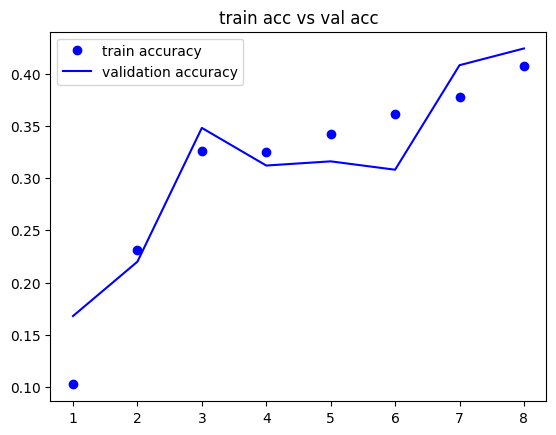

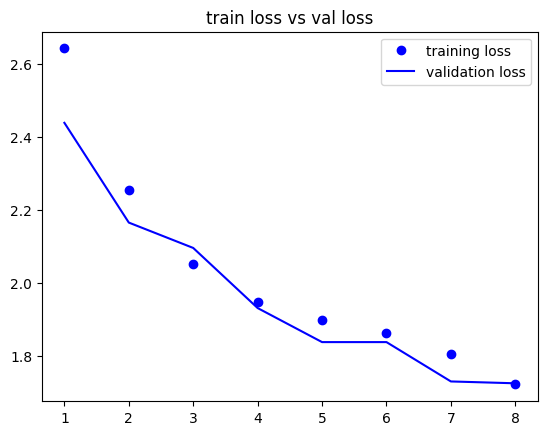

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='train accuracy')
plt.plot(epochs,val_acc, 'b', label='validation accuracy')
plt.title('train acc vs val acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='training loss')
plt.plot(epochs,val_loss, 'b', label = 'validation loss')
plt.title('train loss vs val loss')
plt.legend()

plt.show()

In [ ]:
model.save('FlorANKModel.h5')

In [ ]:
print(os.listdir())
print(os.getcwd())

['train.csv', 'classname.txt', 'val.csv', 'val', 'train', 'FlorANK.h5', 'BetterFlorANKModel.h5', 'training_metrics.json']
/content/drive/MyDrive/8vo/data/Flowers


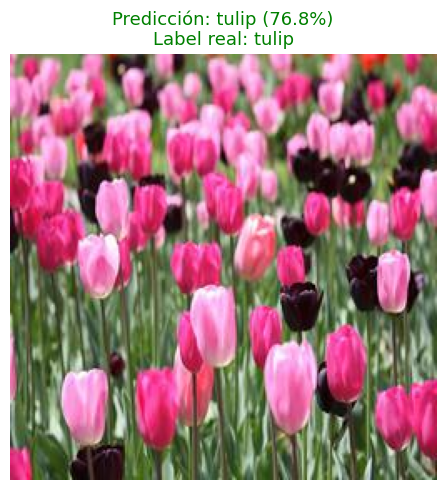

In [ ]:
images, labels = next(iter(test_ds))

idx = 0

img = images[idx].numpy()
true_label = class_names[labels[idx].numpy()]

pred = model.predict(tf.expand_dims(images[idx], axis=0), verbose=0)
pred_label = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
color = 'green' if pred_label == true_label else 'red'
plt.title(
    f"Predicción: {pred_label} ({confidence:.1f}%)\nLabel real: {true_label}",
    color=color,
    fontsize=13
)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Test Set')
plt.ylabel('Label Real')
plt.xlabel('Predicción')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Etapa 3
## Primera mejora

In [ ]:
from tensorflow.keras.applications import VGG16

def get_better_model_compiled():
  vgg = VGG16(weights='imagenet', include_top=False, input_shape=(256,256,3))
  vgg.trainable = False

  model = Sequential([
      vgg,
      GlobalAveragePooling2D(),
      Dense(units=1024, activation='relu', name= 'dense1'),
      Dense(units=14, activation='softmax', name= 'output'),
      ])

  model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model

In [ ]:
bettermodel = get_better_model_compiled()
bettermodel.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 14)             │        14,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,254,350 (58.19 MB)

 Trainable params: 539,662 (2.06 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Entrenamiento

In [ ]:
history = bettermodel.fit(
    train_ds,
    steps_per_epoch=80,
    validation_data=validation_ds,
    epochs=10,
    validation_steps=20

)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 397s 5s/step - accuracy: 0.2825 - loss: 2.2868 - val_accuracy: 0.4500 - val_loss: 1.8059
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 301s 4s/step - accuracy: 0.5050 - loss: 1.6412 - val_accuracy: 0.5250 - val_loss: 1.4566
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 316s 4s/step - accuracy: 0.5950 - loss: 1.3546 - val_accuracy: 0.6550 - val_loss: 1.2122
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 323s 4s/step - accuracy: 0.6475 - loss: 1.1533 - val_accuracy: 0.6300 - val_loss: 1.2036
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.6712 - loss: 1.0701 - val_accuracy: 0.6900 - val_loss: 1.0648
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 323s 4s/step - accuracy: 0.7038 - loss: 0.9933 - val_accuracy: 0.7650 - val_loss: 0.9376
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 318s 4s/step - accuracy: 0.6825 - loss: 0.9667 - val_accuracy: 0.6850 - val_loss: 0.9701
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 317s 4s/step - accuracy: 0.7200 - loss: 0.8980 - val_accuracy: 0.7850 - v

In [ ]:
bettermodel.save('BeSTFlorANKModel.h5')

In [27]:
bettermodel = tf.keras.models.load_model('BeSTFlorANKModel.h5')

In [ ]:
with open("training_metricsvgg.json", "w") as f:
    json.dump(history.history, f)

In [ ]:
with open("training_metrics.json", "r") as f:
    metrics = json.load(f)

print(metrics.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [22]:
with open("training_metricsvgg.json", "r") as f:
    history = json.load(f)

print(history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Evaluación

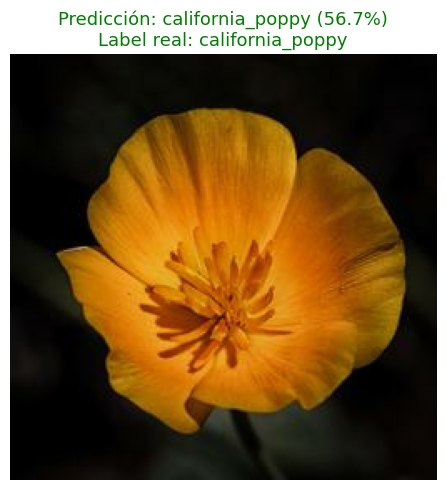

In [28]:
images, labels = next(iter(test_ds))

idx = 0

img = images[idx].numpy()
true_label = class_names[labels[idx].numpy()]

pred = bettermodel.predict(tf.expand_dims(images[idx], axis=0), verbose=0)
pred_label = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
color = 'green' if pred_label == true_label else 'red'
plt.title(
    f"Predicción: {pred_label} ({confidence:.1f}%)\nLabel real: {true_label}",
    color=color,
    fontsize=13
)
plt.tight_layout()
plt.show()

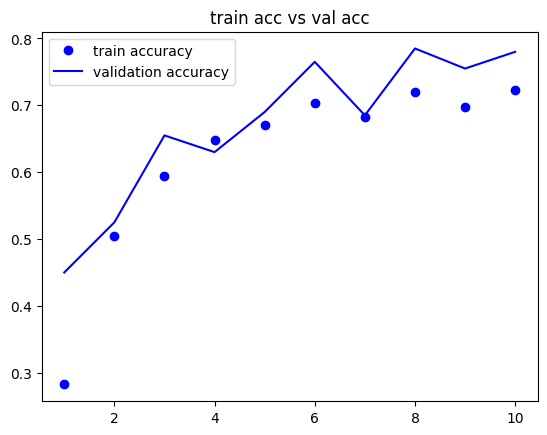

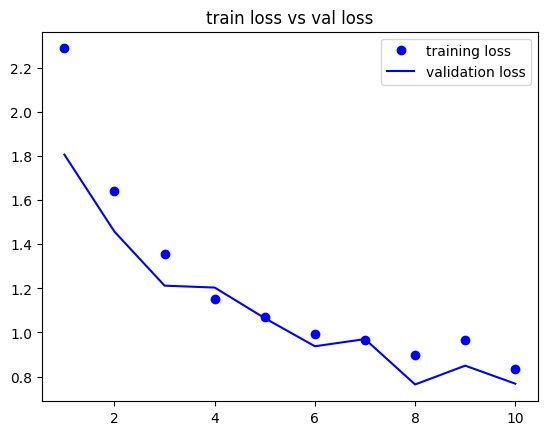

In [29]:
acc = history['accuracy']
val_acc = history['val_accuracy']
loss = history['loss']
val_loss = history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='train accuracy')
plt.plot(epochs,val_acc, 'b', label='validation accuracy')
plt.title('train acc vs val acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='training loss')
plt.plot(epochs,val_loss, 'b', label = 'validation loss')
plt.title('train loss vs val loss')
plt.legend()

plt.show()

                  precision    recall  f1-score   support

         astilbe       0.50      0.57      0.53         7
      bellflower       0.44      1.00      0.61         7
black_eyed_susan       0.78      1.00      0.88         7
       calendula       0.75      0.43      0.55         7
california_poppy       0.80      0.57      0.67         7
       carnation       0.62      0.71      0.67         7
    common_daisy       0.50      0.43      0.46         7
       coreopsis       1.00      0.57      0.73         7
       dandelion       1.00      1.00      1.00         7
            iris       0.88      1.00      0.93         7
            rose       1.00      0.71      0.83         7
       sunflower       1.00      0.57      0.73         7
           tulip       1.00      0.86      0.92         7
      water_lily       0.62      0.71      0.67         7

        accuracy                           0.72        98
       macro avg       0.78      0.72      0.73        98
    weighted

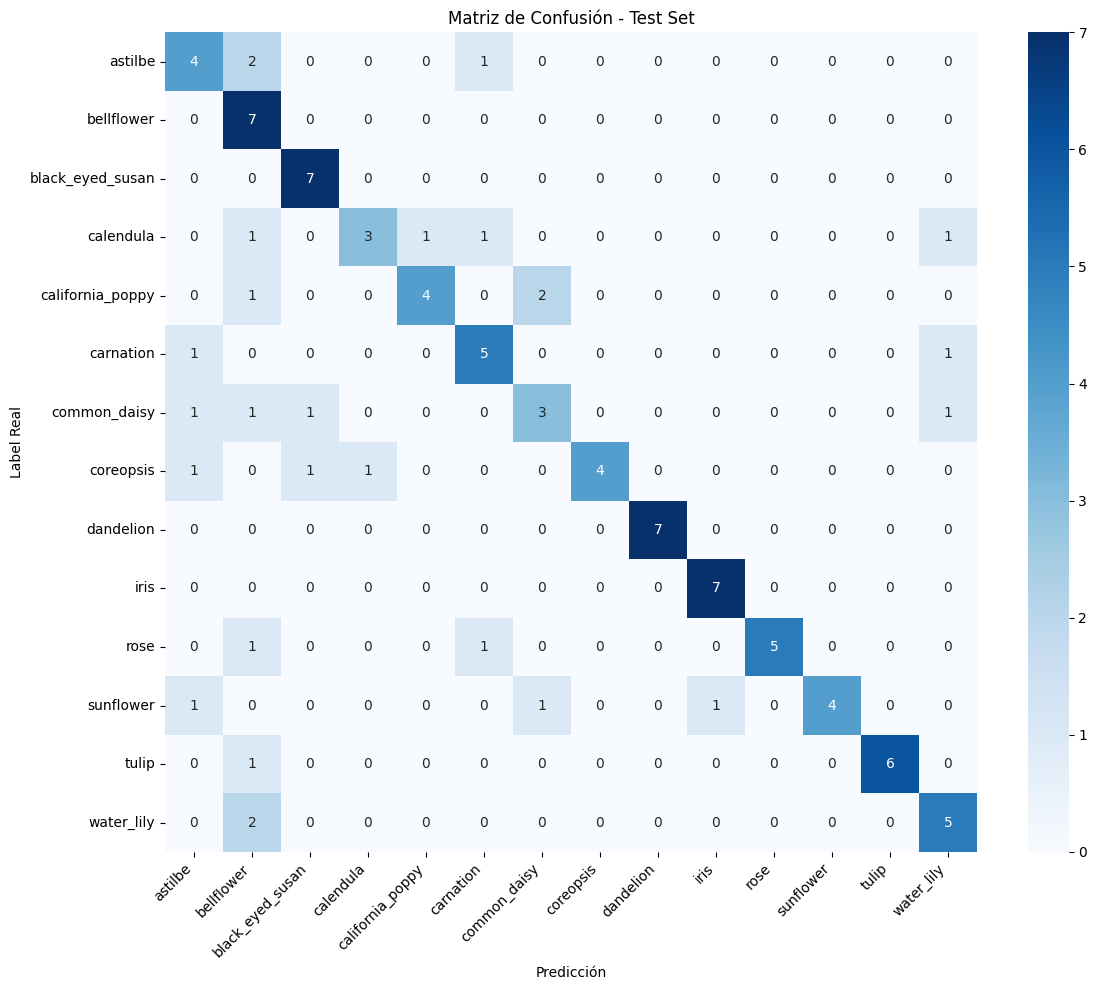

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true, y_pred = [], []

for images, labels in test_ds:
    preds = bettermodel.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Test Set')
plt.ylabel('Label Real')
plt.xlabel('Predicción')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Uso


In [ ]:
def predict_folder_like_testds(folder_path, model, class_names):

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"Found image files in {folder_path}: {image_files}")

    for file in image_files:
        img_path = os.path.join(folder_path, file)

        img = tf.keras.utils.load_img(
            img_path,
            target_size=(256, 256)
        )
        img = tf.keras.utils.img_to_array(img)
        img_norm = img / 255.0

        pred = model.predict(
            tf.expand_dims(img_norm, axis=0),
            verbose=0
        )

        pred_label = class_names[np.argmax(pred)]
        confidence = np.max(pred) * 100

        plt.figure(figsize=(5, 5))
        plt.imshow(img.astype("uint8"))
        plt.axis('off')
        plt.title(
            f"{file}\nPredicción: {pred_label} ({confidence:.1f}%)",
            fontsize=13
        )
        plt.tight_layout()
        plt.show()


In [ ]:
input_folder = "/content/drive/MyDrive/8vo/data/Flowers/usage"
output_folder = "/content/drive/MyDrive/8vo/data/Flowers/usage"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(input_folder):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        img_path = os.path.join(input_folder, file)

        img = tf.keras.utils.load_img(
            img_path,
            target_size=(256, 256)
        )

        save_path = os.path.join(output_folder, file)
        #img = tf.image.rot90(img, k=3)
        tf.keras.utils.save_img(save_path, img)

print("Todas las imágenes fueron forzadas a 256x256 y guardadas.")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Todas las imágenes fueron forzadas a 256x256 y guardadas.


Checking folder: /content/drive/MyDrive/8vo/data/Flowers/usage
All files found in /content/drive/MyDrive/8vo/data/Flowers/usage: ['pngtree-realistic-red-rose-white-background-png-image_11716749.png', 'ivan-jevtic-p7mo8-CG5Gs-unsplash-2-scaled.jpg', "Rosa_'Ambiente',_Bad_Wörishofen,_Alemania,_2019-06-20,_DD_25.jpg"]
Found image files in /content/drive/MyDrive/8vo/data/Flowers/usage: ['pngtree-realistic-red-rose-white-background-png-image_11716749.png', 'ivan-jevtic-p7mo8-CG5Gs-unsplash-2-scaled.jpg', "Rosa_'Ambiente',_Bad_Wörishofen,_Alemania,_2019-06-20,_DD_25.jpg"]


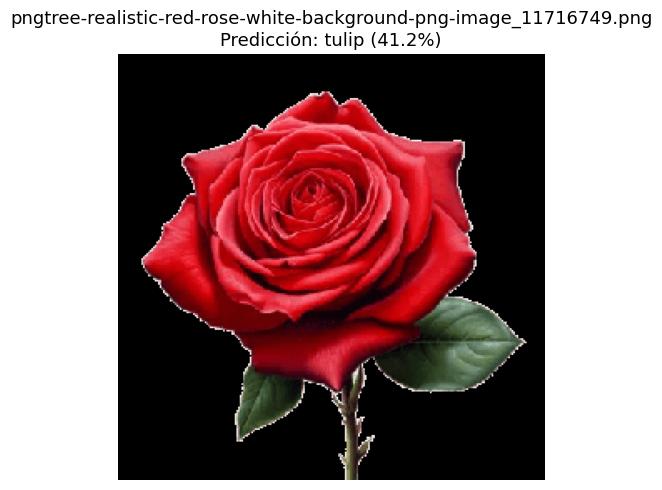

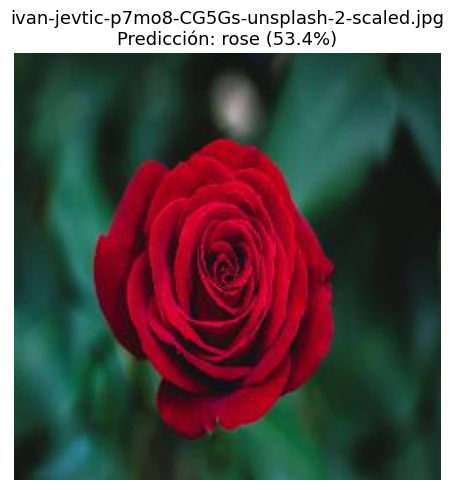

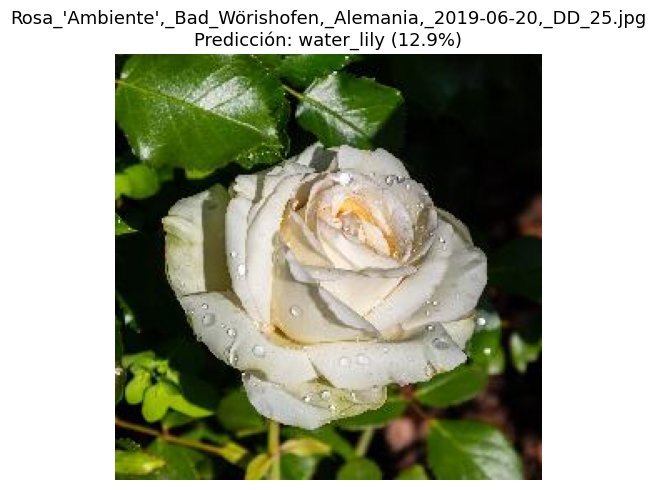

In [ ]:

folder_path = "/content/drive/MyDrive/8vo/data/Flowers/usage"

print(f"Checking folder: {folder_path}")
if not os.path.exists(folder_path):
    print(f"Error: Folder does not exist at {folder_path}")
elif not os.path.isdir(folder_path):
    print(f"Error: Path is not a directory at {folder_path}")
else:
    all_files_in_folder = os.listdir(folder_path)
    print(f"All files found in {folder_path}: {all_files_in_folder}")
    predict_folder_like_testds(
        folder_path=folder_path,
        model=bettermodel,
        class_names=class_names
    )
